# Essential climate variables using the ERA5_Land reanalysis (CDS)

In [1]:
import sys
from pathlib import Path
import cdsapi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import xarray as xr
from src.lakeclimate import cds

import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import AutoMinorLocator
import matplotlib as mpl

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.io.img_tiles import GoogleTiles

project_root = Path.cwd()
data_raw = project_root / "data_cds" / "raw"

Bounding box covering the lake and immediate surroundings

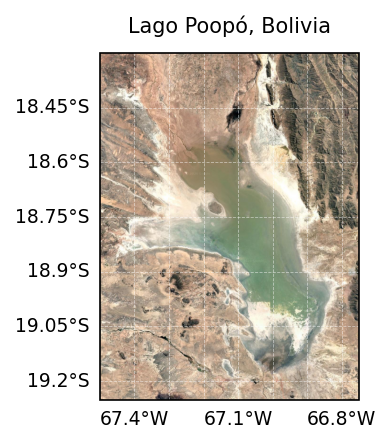

In [3]:
# CDS API expects [North, West, South, East]
poopo_region = [-18.30, -67.50, -19.25, -66.75] 

north, west, south, east = poopo_region

fig = plt.figure(figsize=(4, 3), dpi=150)

tiler = GoogleTiles(style="satellite")
ax = plt.axes(projection=tiler.crs)
ax.set_extent([west, east, south, north], crs=ccrs.PlateCarree())
ax.add_image(tiler, 11)

# Add gridlines with labels
gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.4,
    color="white",
    alpha=0.5,
    linestyle="--"
)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 9}
gl.ylabel_style = {"size": 9}

plt.title("Lago Poopó, Bolivia", fontsize=10, pad=10)
path_to_save = project_root / "figures" / "poopo_region_map..png"
plt.savefig(path_to_save,dpi=150,bbox_inches="tight",pad_inches=0.1)
plt.show()


In [5]:

target_nc = data_raw / "era5_land_2m_temperature_poopo_monthly.nc"
#Name of the dataset in the CDS
cds_dataset = "reanalysis-era5-land-monthly-means"

start_year = 1950
end_year = 2025 

cds_request = {
    "product_type": "monthly_averaged_reanalysis",
    "variable": "2m_temperature",
    "year": [str(y) for y in range(start_year, end_year + 1)],
    "month": [f"{m:02d}" for m in range(1, 13)],
    "time": "00:00",
    "format": "netcdf",
    "download_format": "unarchived",
    "area": poopo_region,  
}

#client = cdsapi.Client()
#client.retrieve(cds_dataset, cds_request, str(target_nc))

print(f"Already downloaded: {target_nc.exists()}")

Already downloaded: True


In [19]:
data_processed = project_root/ "data_cds" / "processed"

ds = xr.open_dataset(target_nc)
var_name = list(ds.data_vars)[0]
#print(f"Variable: {var_name}, units: {ds[var_name].attrs.get('units')}")

monthly_mean_K = cds.area_weighted_mean(ds, var_name)
monthly_mean_C = monthly_mean_K - 273.15
monthly_df = monthly_mean_C.to_dataframe(name="t2m_C").reset_index()

monthly_df = monthly_df.rename(columns={"valid_time": "date"})
monthly_df = monthly_df[["date", "t2m_C"]].sort_values("date")
monthly_df.to_csv(data_processed / "era5_land_t2m_poopo_monthly.csv", index=False)
monthly_df["date"] = pd.to_datetime(monthly_df["date"])
monthly_df["year"] = monthly_df["date"].dt.year
# Keep only complete years (12 months)
annual_counts = monthly_df.groupby("year").size()
complete_years = annual_counts[annual_counts == 12].index
annual_df = (
    monthly_df[monthly_df["year"].isin(complete_years)]
    .groupby("year")["t2m_C"]
    .mean()
    .reset_index()
)
print(annual_df.head())
annual_df.to_csv(data_processed / "era5_land_t2m_poopo_annual.csv", index=False)

   year     t2m_C
0  1950  7.493635
1  1951  7.475684
2  1952  7.641961
3  1953  7.749628
4  1954  7.571948


# Annual air surface temperature anomaly

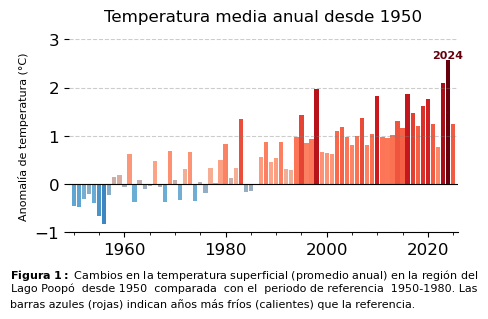

In [ ]:
#Define the temp baseline
baseline = annual_df[(annual_df["year"] >= 1951) & (annual_df["year"] <= 1980)]
baseline_mean_T = baseline["t2m_C"].mean()
annual_df["anomaly_C"] = annual_df["t2m_C"] - baseline_mean_T

anomalies = annual_df["anomaly_C"].values
# Symmetric color scale based on max absolute anomaly
abs_max = max(abs(anomalies.min()), abs(anomalies.max()))
hawkins_colors = [
    "#08306b", "#08519c", "#2171b5", "#6baed6",   # blues (cold)
    "#fcae91", "#fb6a4a", "#cb181d", "#67000d"    # reds (warm)
]
cmap = LinearSegmentedColormap.from_list("warming_stripes", hawkins_colors, N=256)
norm = mcolors.Normalize(vmin=-abs_max, vmax=abs_max)


fig,ax2 = plt.subplots( figsize=(5, 3))

ax2.bar(annual_df["year"], annual_df["anomaly_C"], color=[cmap(norm(a)) for a in annual_df["anomaly_C"].values], width=0.85, edgecolor="none")
ax2.set_ylabel("Anomalía de temperatura (°C)",fontsize = 8)
ax2.axhline(0, color="black", linewidth=0.8)
ax2.tick_params(axis='both', labelsize=12)
ax2.xaxis.set_minor_locator(AutoMinorLocator(4)) 
ax2.grid(
    axis='y',
    linestyle='--',     
    linewidth=0.8,
    color='gray',
    alpha=0.4
)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_alpha(0)
ax2.spines['bottom'].set_alpha(1)
ax2.set_ylim(-1,3)
plt.xlim(1949,2026)


ax2.set_title("Temperatura media anual desde 1950",fontsize = 12,loc="center", y=1.05)
texto = (r"$\mathbf{Figura\ 1:}$ Cambios en la temperatura superficial (promedio anual) en la región del")
texto2 = ("Lago Poopó  desde 1950  comparada  con el  periodo de referencia  1950-1980. Las")
texto3 = ("barras azules (rojas) indican años más fríos (calientes) que la referencia.")
ax2.text(0.45, -0.18, texto, transform= ax2.transAxes, ha="center", va="top", fontsize=8, linespacing=1.5, wrap=True, multialignment="center")
ax2.text(0.45, -0.26, texto2, transform= ax2.transAxes, ha="center", va="top", fontsize=8, linespacing=1.5, wrap=True, multialignment="center")
ax2.text(0.37, -0.34, texto3, transform= ax2.transAxes, ha="center", va="top", fontsize=8, linespacing=1.5, wrap=True, multialignment="center")

# Highlight the hottest year
hot_temp = annual_df["anomaly_C"].max()
hot_year = annual_df["year"][annual_df["anomaly_C"].idxmax()]
ax2.text(
    hot_year,
    hot_temp +0.05,
    str(hot_year),
    color="#67000d",
    fontsize=8,
    fontweight='bold',
    ha='center'
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.2) 
path_to_save = project_root / "figures" / "2mt_anomaly_1951-1980_bl_poopo.png"
plt.savefig(path_to_save, dpi=150, bbox_inches="tight")
plt.show()

# Annual temperature

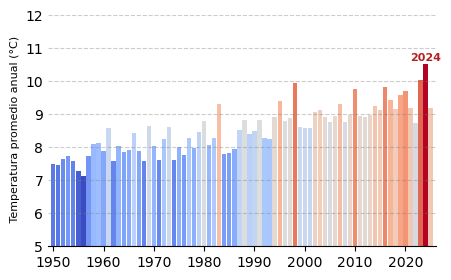

In [22]:

norm = mpl.colors.Normalize(vmin=annual_df["t2m_C"].min(), vmax=annual_df["t2m_C"].max())

# Blue -> Red colormap
cmap = mpl.colormaps["coolwarm"]
colors = cmap(norm(annual_df["t2m_C"]))

fig, ax1 = plt.subplots(figsize=(5, 3))

ax1.bar(annual_df["year"] , annual_df["t2m_C"] , color=colors, width=0.85)
ax1.set_ylabel(f" Temperatura promedio anual (°C)", fontsize=8)
ax1.tick_params(axis='both', labelsize=10)
ax1.tick_params(axis='y', length=0)
ax1.set_xlim(annual_df["year"].min()-1, annual_df["year"].max()+1)
ax1.set_ylim(5,12)
ax1.grid(
    axis='y',
    linestyle='--',     
    linewidth=0.8,
    color='gray',
    alpha=0.4
)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_alpha(0)
ax1.spines['bottom'].set_alpha(1)

# Highlight the hottest year
hot_temp = annual_df["t2m_C"].max()
hot_year = annual_df["year"][annual_df["t2m_C"].idxmax()]
ax1.text(
    hot_year,
    hot_temp + 0.1,
    str(hot_year),
    color='firebrick',
    fontsize=8,
    fontweight='bold',
    ha='center'
)
path_to_save = project_root / "figures" / "Poopo_2mt_1940-2025.png"
plt.savefig(path_to_save, dpi=150, bbox_inches="tight")
plt.show()


# Precipitation

variable = "total_precipitation"

In [23]:
data_processed = project_root/ "data_cds" / "processed"
target_nc = data_raw / "era5_land_tp_poopo_monthly.nc"

tp = xr.open_dataset(target_nc)
# Monthly accumulation in mm
monthly_tp = cds.era5_monthly_to_mm(tp, "tp", 1000)
monthly_tp.to_csv( data_processed / "era5_land_tp_poopo_monthly.csv", index=False)
annual_tp = (monthly_tp.groupby(monthly_tp["valid_time"].dt.year)[f"tp_mm"].sum().reset_index().rename(columns={"valid_time":"year"}))
print(annual_tp.head())
annual_tp.to_csv( data_processed / "era5_land_tp_poopo_annual.csv", index=False)


   year       tp_mm
0  1950  676.186910
1  1951  839.243670
2  1952  940.597850
3  1953  893.861926
4  1954  864.735015


# Annual preciptation 

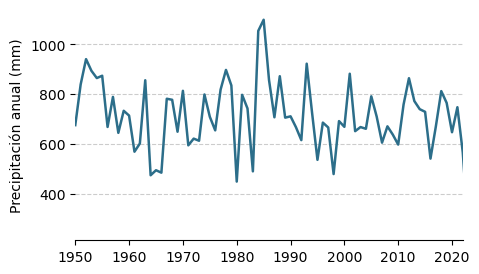

In [24]:

fig, ax1 = plt.subplots(figsize=(5, 3))

ax1.plot(annual_tp["year"], annual_tp["tp_mm"], color="#2C6E8A", linewidth=1.8)
ax1.set_ylabel("Precipitación anual (mm)", fontsize = 10)
ax1.spines[["top", "right"]].set_visible(False)
ax1.grid(axis="y", linestyle=":", alpha=0.4)
ax1.set_xlim(1950, 2022)
ax1.grid(
    axis='y',
    linestyle='--',     
    linewidth=0.8,
    color='gray',
    alpha=0.4
)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_alpha(0)
ax1.spines['bottom'].set_alpha(1)

path_to_save = project_root / "figures" / "pt_era5_land.png"
plt.savefig(path_to_save, dpi=150, bbox_inches="tight")
plt.show()


# Annual precipitation anomaly

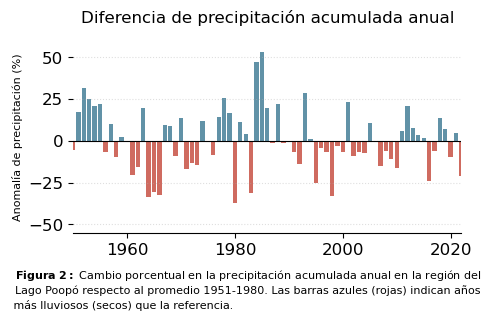

In [25]:
# Define baseline period
baseline_period = annual_tp[(annual_tp["year"] >= 1951) & (annual_tp["year"] <= 1980)]
baseline_mean = baseline_period["tp_mm"].mean()

annual_tp["anomaly_pct"] = (annual_tp["tp_mm"] - baseline_mean) / baseline_mean * 100

fig,ax2 = plt.subplots( figsize=(5, 3))

colors = ["#C0392B" if a < 0 else "#2C6E8A" for a in annual_tp["anomaly_pct"]]
ax2.bar(annual_tp["year"], annual_tp["anomaly_pct"], color=colors, alpha=0.75)
ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_ylabel("Anomalía de precipitación (%)",fontsize = 8)
ax2.grid(axis="y", linestyle=":", alpha=0.4)
ax2.tick_params(axis='both', labelsize=12)
ax2.set_yticks([-50,-25,0,25,50])
ax2.set_ylim(-55,60)

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_alpha(0)
ax2.spines['bottom'].set_alpha(1)

ax2.set_title("Diferencia de precipitación acumulada anual",fontsize = 12,loc="center", y=1.05)
texto = (r"$\mathbf{Figura\ 2:}$ Cambio porcentual en la precipitación acumulada anual en la región del")
texto2 = ("Lago Poopó respecto al promedio 1951-1980. Las barras azules (rojas) indican años")
texto3 = (" más lluviosos (secos) que la referencia.")
ax2.text(0.45, -0.18, texto, transform= ax2.transAxes, ha="center", va="top", fontsize=8, linespacing=1.5, wrap=True, multialignment="center")
ax2.text(0.45, -0.27, texto2, transform= ax2.transAxes, ha="center", va="top", fontsize=8, linespacing=1.5, wrap=True, multialignment="center")
ax2.text(0.125, -0.35, texto3, transform= ax2.transAxes, ha="center", va="top", fontsize=8, linespacing=1.5, wrap=True, multialignment="center")


plt.xlim(1950,2022)
plt.tight_layout()
plt.subplots_adjust(bottom=0.2) 
path_to_save = project_root / "figures" / "tp_1951-1980_bl_poopo.png"
plt.savefig(path_to_save, dpi=150, bbox_inches="tight")
plt.show()


# Evapotranspiration